In [ ]:
'''
Assignment (18/03/2026)

Assignment Name : Customer Segmentation
Description : Perform K-Means clustering on a mall dataset and describe customer groups.
'''

   CustomerID  Annual Income (k$)  Spending Score (1-100)
0           1                 117                      52
1           2                  66                      96
2           3                 107                       4
3           4                  29                      94
4           5                 121                      23


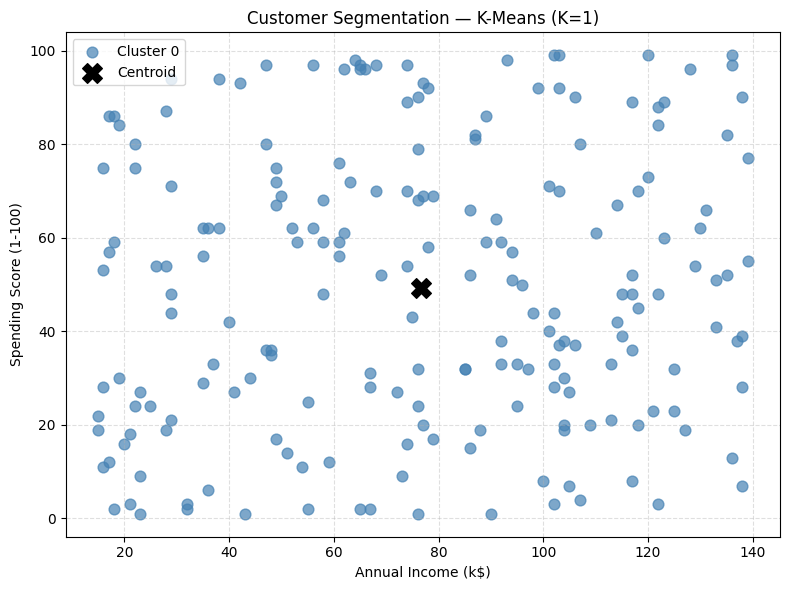


Cluster Summary:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                      76.6                    49.3

Cluster 0 → All customers grouped as one: Average shoppers


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
np.random.seed(42)
n = 200
data = {
    'CustomerID': range(1, n + 1),
    'Annual Income (k$)': np.random.randint(15, 140, n),
    'Spending Score (1-100)': np.random.randint(1, 100, n)
}
df = pd.DataFrame(data)
print(df.head())
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=1, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            color='steelblue', s=60, alpha=0.7, label='Cluster 0')
centre = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centre[:, 0], centre[:, 1],
            color='black', marker='X', s=200, label='Centroid')
plt.title('Customer Segmentation — K-Means (K=1)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print("\nCluster Summary:")
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))
print("\nCluster 0 → All customers grouped as one: Average shoppers")